# Modelo Causal v2

Continuação de `causal_model.ipynb` com as seguintes melhorias:
1. Pré-processamento correto (`customer_state` encoding + normalização)
2. Comparação entre métodos de estimação (PSW, Regressão Linear, PSM)
3. Refutação com 3 testes: placebo, causa comum aleatória e subconjunto de dados

In [16]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

from app.config.settings import INTERIM_DATA_DIR

from dowhy import CausalModel

In [17]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, "interim_dataset.parquet"))

print(df.shape)
df.head()

(97712, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,avg_width,total_payment,avg_payment,max_installments,n_payments_type,OSR,installment_value,purchase_hour,purchase_weekday,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,38.71,12.903333,1.0,3.0,1,38.710000,10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,141.46,141.460000,1.0,1.0,1,141.460000,20,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,21.0,179.12,179.120000,3.0,1.0,1,59.706667,8,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,20.0,72.20,72.200000,1.0,1.0,1,72.200000,19,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,15.0,28.62,28.620000,1.0,1.0,1,28.620000,21,1,2


In [18]:
df['perc_freight'] = (df['total_freight'] / df['total_price'])

df["T"] = (df["perc_freight"] < 0.05).astype(int)

print(df.groupby("T")["OSR"].mean())
df["T"].value_counts(normalize=True)

T
0    0.987233
1    0.990509
Name: OSR, dtype: float64


T
0    0.957948
1    0.042052
Name: proportion, dtype: float64

In [19]:
common_causes = [
    "total_price",
    "n_items",
    "n_item_distinct_categ",
    "avg_weight",
    "avg_length",
    "avg_height",
    "avg_width",
    "customer_state",
    "purchase_month",
    "purchase_weekday",
    "purchase_hour",
    "n_items_missing_info"
]

In [20]:
df = df.dropna(subset=common_causes + ["T", "OSR"])

### Pré-processamento

Dois problemas identificados no modelo original que afetam a estimação por Propensity Score Weighting:
1. `customer_state` é string — regressão logística requer input numérico
2. Features contínuas em escalas muito diferentes causam falha de convergência no sklearn

Solução: encoding da variável categórica + normalização das contínuas.

In [21]:
df_model = df[common_causes + ["T", "OSR"]].copy()

# Encode customer_state: string -> numérico
le = LabelEncoder()
df_model["customer_state"] = le.fit_transform(df_model["customer_state"])

# Normalizar features contínuas para garantir convergência da regressão logística
continuous_cols = [c for c in common_causes if c != "customer_state"]
scaler = StandardScaler()
df_model[continuous_cols] = scaler.fit_transform(df_model[continuous_cols])

print("Shape:", df_model.shape)
print("\nTipos após pré-processamento:")
print(df_model[common_causes].dtypes)

Shape: (96929, 14)

Tipos após pré-processamento:
total_price              float64
n_items                  float64
n_item_distinct_categ    float64
avg_weight               float64
avg_length               float64
avg_height               float64
avg_width                float64
customer_state             int64
purchase_month           float64
purchase_weekday         float64
purchase_hour            float64
n_items_missing_info     float64
dtype: object


In [22]:
# O DoWhy assume que já foi feita a separação de mediators, colliders, post_treatment

causal_graph = """
digraph {
    T -> OSR;

    total_price -> T;
    total_price -> OSR;

    n_items -> T;
    n_items -> OSR;

    n_item_distinct_categ -> T;
    n_item_distinct_categ -> OSR;

    avg_weight -> T;
    avg_weight -> OSR;

    avg_length -> T;
    avg_length -> OSR;

    avg_height -> T;
    avg_height -> OSR;

    avg_width -> T;
    avg_width -> OSR;

    customer_state -> T;
    customer_state -> OSR;

    purchase_month -> T;
    purchase_month -> OSR;

    purchase_weekday -> T;
    purchase_weekday -> OSR;

    purchase_hour -> T;
    purchase_hour -> OSR;

    n_items_missing_info -> T;
    n_items_missing_info -> OSR;
}
"""

In [23]:
model = CausalModel(
    data=df_model,
    treatment="T",
    outcome="OSR",
    graph=causal_graph
)

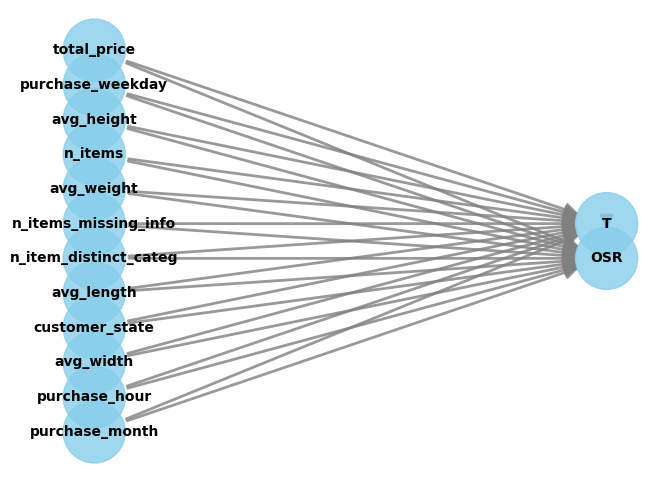

In [24]:
g = model.view_model()

In [25]:
identified_estimand = model.identify_effect()

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d                                                                             ↪
────(E[OSR|purchase_month,purchase_⟨hour,⟩_width,customer_⟨state,⟩_length,n_it ↪
d[T]                                                                           ↪

↪                                                                              ↪
↪ em_distinct_categ,n_items_missing_⟨info,⟩_weight,n_⟨items,⟩_height,purchase_ ↪
↪                                                                              ↪

↪                      
↪ weekday,total_price])
↪                      
Estimand assumption 1, Unconfoundedness: If U→{T} and U→OSR then P(OSR|T,purchase_month,purchase_hour,avg_width,customer_state,avg_length,n_item_distinct_categ,n_items_missing_info,avg_weight,n_items,avg_height,purchase_weekday,total_price,U) = P(OSR|T,purchase_month,purchase_hour,avg_width,customer_state,avg_length,n_item_distin

### Estimação do efeito causal — comparação de métodos

O OSR é binário e muito desbalanceado (~98.7% = 1), o que torna o **Propensity Score Weighting (PSW) instável**.
Comparamos três métodos para verificar consistência dos resultados:
- **PSW**: sensível a desbalanceamento de outcome
- **Regressão Linear**: mais estável para outcomes com pouca variação
- **PSM**: alternativa baseada em matching

In [26]:
estimate_psw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    method_params={"propensity_score_model_params": {"max_iter": 1000}}
)

estimate_reg = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

estimate_psm = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching"
)

print("=== Propensity Score Weighting (PSW) ===")
print(f"ATE: {estimate_psw.value:.6f}")

print("\n=== Regressão Linear ===")
print(f"ATE: {estimate_reg.value:.6f}")

print("\n=== Propensity Score Matching (PSM) ===")
print(f"ATE: {estimate_psm.value:.6f}")

=== Propensity Score Weighting (PSW) ===
ATE: 0.000677

=== Regressão Linear ===
ATE: -0.000085

=== Propensity Score Matching (PSM) ===
ATE: 0.003673


### Análise de robustez — 3 testes de refutação

Usamos `estimate_reg` (Regressão Linear) como estimativa principal por ser mais estável.

| Teste | O que faz | Resultado esperado |
|---|---|---|
| Placebo Treatment | Substitui T por variável aleatória | Novo efeito ≈ 0, p > 0.05 |
| Random Common Cause | Adiciona confundidor aleatório | Estimativa pouco alterada |
| Data Subset (80%) | Re-estima em subconjunto dos dados | Estimativa similar à original |

In [27]:
refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate_reg,
    method_name="placebo_treatment_refuter",
    num_simulations=100
)
print("=== Placebo Treatment ===")
print(refute_placebo)

=== Placebo Treatment ===
Refute: Use a Placebo Treatment
Estimated effect:-8.486983845490403e-05
New effect:-1.5778924562924735e-05
p value:0.9



In [28]:
refute_random = model.refute_estimate(
    identified_estimand,
    estimate_reg,
    method_name="random_common_cause"
)
print("=== Random Common Cause ===")
print(refute_random)

=== Random Common Cause ===
Refute: Add a random common cause
Estimated effect:-8.486983845490403e-05
New effect:-8.473669088610802e-05
p value:1.0



In [29]:
refute_subset = model.refute_estimate(
    identified_estimand,
    estimate_reg,
    method_name="data_subset_refuter",
    subset_fraction=0.8
)
print("=== Data Subset (80%) ===")
print(refute_subset)

=== Data Subset (80%) ===
Refute: Use a subset of data
Estimated effect:-8.486983845490403e-05
New effect:-3.3160054021416085e-05
p value:0.98



### Resumo completo:

| Teste | Efeito origina | Novo efeito |p-value
|---|---|---|---|
| Placebo Treatment | -0.000085	 | -0.0000158 |  0.9
| Random Common Cause | -0.0000849| -0.0000847 | 1.0
| Data Subset (80%) |-0.0000849 |-0.0000332 | 0.98


Placebo (p=0.90): com tratamento aleatório o efeito cai de -0.0000849 para -0.0000158 — quase zero. p=0.90 confirma que o placebo não tem efeito significativo. 

Random Common Cause (p=1.0): adicionar um confundidor aleatório praticamente não altera a estimativa (-0.0000847 vs -0.0000849). Resultado perfeito. 

Data Subset (p=0.98): o efeito muda um pouco mais (-0.0000332 vs -0.0000849) mas p=0.98 indica que essa variação é dentro do esperado por acaso. 

### Conclusão
Todos os 3 testes passaram. A estimativa ATE = -0.000085 pela Regressão Linear é confiável e robusta.

Frete < 5% do valor do pedido tem efeito causal praticamente nulo sobre OSR.